In [693]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns 
warnings.filterwarnings('ignore')

In [694]:
sber = pd.read_csv('data/SBRF.txt')

In [695]:
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result


In [696]:
sber_15 = good_dataframe(sber, '5 min')
sber_15

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:30:00,SBRF,5 min,2301.0,2346.0,2265.0,2334.0,769
1,2009-01-11 10:35:00,SBRF,5 min,2334.0,2338.0,2320.0,2327.0,399
2,2009-01-11 10:40:00,SBRF,5 min,2322.0,2341.0,2322.0,2340.0,1825
3,2009-01-11 10:45:00,SBRF,5 min,2341.0,2355.0,2340.0,2350.0,2444
4,2009-01-11 10:50:00,SBRF,5 min,2350.0,2376.0,2349.0,2370.0,1614
...,...,...,...,...,...,...,...,...
675268,2025-06-30 23:25:00,SBRF,5 min,29865.0,29865.0,29847.0,29849.0,23
675269,2025-06-30 23:30:00,SBRF,5 min,29849.0,29853.0,29849.0,29849.0,51
675270,2025-06-30 23:35:00,SBRF,5 min,29849.0,29849.0,29846.0,29846.0,23
675271,2025-06-30 23:40:00,SBRF,5 min,29846.0,29851.0,29845.0,29845.0,92


# Смещение данных

In [697]:
def shift_features_2_candle(data):
    data_c = data.copy()
    for i in ['open', 'close', 'low', 'high', 'volume', 'time']:
        data_c[f"{i}_N"] = data[i]
        data_c[f'{i}_N-1'] = data[i].shift(1)
    data_c.drop(['open', 'close', 'low', 'high', 'volume', 'time'], axis=1, inplace=True)
    data_c.dropna(inplace=True)
    for i in ['open', 'close', 'low', 'high', 'volume']:
        data_c[f'{i}_N-1'] = data_c[f'{i}_N-1'].astype('int32')
    return data_c

df = shift_features_2_candle(sber_15)
df

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,volume_N,volume_N-1,time_N,time_N-1
1,SBRF,5 min,2334.0,2301,2327.0,2334,2320.0,2265,2338.0,2346,399,769,2009-01-11 10:35:00,2009-01-11 10:30:00
2,SBRF,5 min,2322.0,2334,2340.0,2327,2322.0,2320,2341.0,2338,1825,399,2009-01-11 10:40:00,2009-01-11 10:35:00
3,SBRF,5 min,2341.0,2322,2350.0,2340,2340.0,2322,2355.0,2341,2444,1825,2009-01-11 10:45:00,2009-01-11 10:40:00
4,SBRF,5 min,2350.0,2341,2370.0,2350,2349.0,2340,2376.0,2355,1614,2444,2009-01-11 10:50:00,2009-01-11 10:45:00
5,SBRF,5 min,2371.0,2350,2361.0,2370,2355.0,2349,2380.0,2376,746,1614,2009-01-11 10:55:00,2009-01-11 10:50:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675268,SBRF,5 min,29865.0,29850,29849.0,29865,29847.0,29842,29865.0,29865,23,156,2025-06-30 23:25:00,2025-06-30 23:20:00
675269,SBRF,5 min,29849.0,29865,29849.0,29849,29849.0,29847,29853.0,29865,51,23,2025-06-30 23:30:00,2025-06-30 23:25:00
675270,SBRF,5 min,29849.0,29849,29846.0,29849,29846.0,29849,29849.0,29853,23,51,2025-06-30 23:35:00,2025-06-30 23:30:00
675271,SBRF,5 min,29846.0,29849,29845.0,29846,29845.0,29846,29851.0,29849,92,23,2025-06-30 23:40:00,2025-06-30 23:35:00


# Напишем функцию детекции свечного паттерна

In [698]:
def detection_bullish_engulfing_pattern(data):
    """
    Функция для детекции бычьего паттерна 'поглощение' (Bullish Engulfing) на ценовых данных."""

    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N_1 < close_N) & 
        (close_N_1 > open_N)
    )
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
    
    return data

In [699]:
def detection_bullish_harami_pattern(data):
    """
    Функция для детекции бычьего паттерна 'харами' (Bullish Harami) на ценовых данныx.
    Паттерн Харами состоит из большой медвежьей свечи, за которой следует маленькая бычья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для бычьего харами
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (close_N_1 < open_N) & 
        (open_N_1 > close_N))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [700]:
def detection_break_in_the_clouds(data):
    """Первая свеча падающая, вторая растущая, открытие второй свечи ниже закрытия первой. перекрытия нет.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'break_in_the_clouds'
    
    # Векторизованные вычисления
    close_N = data['close_N']
    close_N_1 = data['close_N-1']
    open_N = data['open_N']
    open_N_1 = data['open_N-1']
    
    body_N = data['close_N'] - data['open_N']
    body_N_1 = data['close_N-1'] - data['open_N-1']
    
    # Базовое условие для просвета в облаках
    base_condition = (
        (body_N_1 < 0) & 
        (body_N > 0) &
        (open_N < close_N_1) & 
        (close_N < open_N_1))
    
    # Отмечаем 2 свечи паттерна
    pattern_mask = base_condition
    data.loc[pattern_mask, 'pattern'] = 1
    # Сигнал - следующая свеча после завершения паттерна
    data.loc[pattern_mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [701]:
df_b = detection_bullish_engulfing_pattern(df)

Напишем функцию, которая считает прибыль или убыток при входе на цене открытия после завершения паттерна, держит позицию N следующих свечей, где N пробегает [1, 2, ..., 10, 15, 20, ..., 50] и выходит на закрытии последней свечи.

In [702]:
def filter_min_distance(data, column, N):
    data = data.copy()
    one_index = data[data[column] == 1].index
    
    distances = np.diff(one_index)
    mask = [True]
    
    current_distance = 0
    for dist in distances:
        current_distance += dist
        if current_distance >= N:
            mask.append(True)
            current_distance=0
        else:
            mask.append(False)
            
    # Данные для удаления
    to_remove = one_index[np.where(~np.array(mask))[0]]
    data.loc[to_remove, column] = 0
    
    return data
        

In [703]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics

def lst_trade_statistics_bull(data, commission=0.001):
   
   # Удалим сперва все отметки паттерна и сигнала с последних 51 строки
   data.loc[len(data) - 51 : len(data), ['pattern', 'signal']] = 0

   # Проходимся циклом по периодам удержания позиции
   all_strategy = []
   for N in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50]:
      
      data_h = filter_min_distance(data, 'signal', N) # Получаем фильтрованные данные
      strategy = [] # Список для результатов стратегии
      
      # Блок для определения цены входа и выхода
      exit_candidate = data_h['open_N'].shift(-N)
      is_entry = data_h['signal'] == 1
      entry_price = data_h['open_N'][is_entry]
      exit_price = exit_candidate[is_entry]
      
      # Считаем результат
      capital = 100_000
      profit_percent = (exit_price.values - entry_price.values) / entry_price.values # % доход за сделку
      profit = exit_price - entry_price
      
      # Считаем прибыль стратегии купи и держи:
      first_buy = data.loc[1, 'close_N']
      last_sell = data.loc[len(data) - 51, 'close_N']
      BH_strategy = ((last_sell - first_buy) / first_buy) * 100
      
      # Считаем результат стратегии 
      def calculate_relative_drawdown(lst):
        running_max = np.maximum.accumulate(lst)
        drawdown = (running_max - lst) 
        return np.max(drawdown)
     
      # Чистая прибыль
      absolut_profit_net = np.where(profit >= 0, profit * (1 - commission), profit * (1 + commission))
      percent_profit_net = np.where(profit_percent >= 0, profit_percent * (1 - commission), profit_percent * (1 + commission))
      total_return_net = (np.prod(1 + percent_profit_net) - 1) * 100 # общая прибыль в %
      capital_curve = capital * np.cumprod(1 + percent_profit_net)
      # Статистика
      
      # Названия
      strategy_name = data['strategy'][1]
      per = data['per'][1]
      ticker = data['ticker'][1]
      
      # Считаем R^2 линейной регрессии, построенной по графику дохода
      X = np.array(list(range(len(capital_curve)))).reshape(-1, 1)
      y = np.array(capital_curve)
      lin = LinearRegression()
      
      lin.fit(X, y)
      y_pred = lin.predict(X)
      r2 = metrics.r2_score(y, y_pred)
      all_strategy.append({'strategy' : strategy_name,
                           'ticker' : ticker,
                           'period' : per,
                           'N' : N,
                           'trades' : len(absolut_profit_net),
                           'win_rate' : np.round(np.mean(percent_profit_net > 0), 2), # Считаем по % доходу после уплаты комиссии
                           'profit_factor(%)' : np.round(np.sum(percent_profit_net[percent_profit_net > 0]) / np.abs(np.sum(percent_profit_net[percent_profit_net < 0])), 3),
                           'total_return' : np.round(total_return_net, 2), 'capital_curve' : capital_curve, 'profit' : profit,
                           'max_drawdown' : calculate_relative_drawdown(capital_curve), 'r2' : np.round(r2, 2),
                           'strategy_buy_and_hold' : BH_strategy})
   return pd.DataFrame(all_strategy)

result = lst_trade_statistics_bull(df_b)

result.head()

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return,capital_curve,profit,max_drawdown,r2,strategy_buy_and_hold
0,bullish_engulfing_pattern,SBRF,5 min,1,19601,0.46,1.023,21.46,"[100384.06663818881, 100213.31990801918, 10021...",3 9.0 107 -4.0 154 0.0 2...,25285.461978,0.47,1182.939407
1,bullish_engulfing_pattern,SBRF,5 min,2,19601,0.46,0.987,-24.50,"[101280.22212729605, 100892.61230522941, 10076...",3 30.0 107 -9.0 154 -3.0 2...,31521.060935,0.13,1182.939407
2,bullish_engulfing_pattern,SBRF,5 min,3,19040,0.47,0.975,-42.94,"[101066.85177274668, 100594.10448945453, 10020...",3 25.0 107 -11.0 154 -9.0 2...,53858.018110,0.24,1182.939407
3,bullish_engulfing_pattern,SBRF,5 min,4,18513,0.47,0.983,-37.08,"[100896.15548910722, 100681.63328935234, 10033...",3 21.0 107 -5.0 154 -8.0 2...,49710.538271,0.03,1182.939407
4,bullish_engulfing_pattern,SBRF,5 min,5,17992,0.48,0.994,-25.17,"[101152.19991456643, 100765.08004666909, 10063...",3 27.0 107 -9.0 154 -3.0 2...,56308.738675,0.03,1182.939407


Отбираем наилучшие стратегии для дальнейшего анализа с помощью моделей машинного обучения

In [704]:
l = []
for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
    sber_tm = good_dataframe(sber, i)
    l.append(sber_tm)

In [705]:
all_strategy = []
for detec in [detection_bullish_engulfing_pattern, detection_bullish_harami_pattern, detection_break_in_the_clouds]:
    for i in l:
        detection_data = detec(shift_features_2_candle(i))
        final_result = lst_trade_statistics_bull(detection_data)
        all_strategy.append(final_result)
        
    

In [706]:
combined_df = pd.concat(all_strategy, ignore_index=True)



In [707]:
combined_df = combined_df[combined_df['trades'] > 800]

In [708]:
combined_df['profit_factor_rank'] = combined_df['profit_factor(%)'].rank() # Больше лучше
combined_df['r2_rank'] = combined_df['r2'].rank() # Больше лучше
combined_df['max_drawdown_rank'] = combined_df['max_drawdown'].rank(ascending=False) # Меньше лучше
combined_df['best_model'] = combined_df['profit_factor_rank'] + combined_df['max_drawdown_rank'] + combined_df['r2_rank']
combined_df.sort_values('best_model', ascending=False, ignore_index=True, inplace=True)

In [709]:
combined_df

,strategy,ticker,period,N,trades,win_rate,profit_factor(%),total_return,capital_curve,profit,max_drawdown,r2,strategy_buy_and_hold,profit_factor_rank,r2_rank,max_drawdown_rank,best_model
0,break_in_the_clouds,SBRF,2h,3,1344,0.51,1.193,163.56,"[99094.31279620853, 100291.83560044334, 95227....",11 -21.0 18 27.0 24 -112.0 3...,49314.024996,0.89,1158.725406,234.0,246.0,220.0,700.0
1,bullish_engulfing_pattern,SBRF,30 min,2,4130,0.50,1.121,112.76,"[99871.66666666667, 99700.33583833191, 100127....",6 -3.0 14 -4.0 17 10.0 2...,31846.589770,0.88,1164.720920,198.5,244.5,240.0,683.0
2,bullish_engulfing_pattern,SBRF,2h,10,929,0.52,1.165,156.67,"[98499.57173447538, 88248.08025977382, 85151.3...",4 -35.0 41 -212.0 57 -59....,66745.202076,0.85,1158.725406,224.5,240.5,187.0,652.0
3,break_in_the_clouds,SBRF,2h,1,1411,0.52,1.149,53.42,"[99309.95260663507, 99754.4447332212, 96066.13...",11 -16.0 18 10.0 24 -82.0 38 ...,38933.928275,0.69,1158.725406,220.0,193.5,234.0,647.5
4,break_in_the_clouds,SBRF,2h,8,1086,0.52,1.121,94.62,"[96592.89099526066, 89188.74132829512, 82254.5...",11 -79.0 24 -170.0 38 -160.0 5...,67732.595397,0.78,1158.725406,198.5,223.5,183.0,605.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,bullish_engulfing_pattern,SBRF,15 min,9,6202,0.50,1.040,22.60,"[99229.01155327343, 98634.99388223219, 99383.1...",16 -18.0 56 -14.0 154 17....,185763.721353,0.06,1162.558238,94.0,43.0,58.0,195.0
242,bullish_engulfing_pattern,SBRF,15 min,40,3542,0.51,1.046,20.74,"[100645.3488372093, 98292.36803877447, 98771.5...",23 15.0 202 -49.0 242 10....,348668.010442,0.14,1162.558238,101.5,65.5,24.0,191.0
243,bullish_engulfing_pattern,SBRF,5 min,40,9211,0.50,1.035,69.53,"[99871.72148654421, 99616.90858966732, 98594.1...",3 -3.0 107 -6.0 154 -24....,152172.984778,0.00,1182.939407,88.0,7.5,85.0,180.5
244,break_in_the_clouds,SBRF,5 min,9,22142,0.51,1.032,94.93,"[99529.8462852263, 99487.26962875984, 99358.93...",23 -11.0 33 -1.0 57 -3....,162499.821603,0.01,1182.939407,85.0,19.0,74.0,178.0


In [710]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# for i in range(100):
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#     # Первый график (ваш существующий)
#     ax1.set_title(f'{i} - Кумулятивная сумма сделок')
#     cumsume = np.cumsum(combined_df.loc[i, "profit"])
#     sns.lineplot(x=range(len(cumsume)), y=cumsume, ax=ax1)
#     ax1.set_xlabel('Номер сделки')
#     ax1.set_ylabel('Кумулятивная прибыль')
#     ax1.grid(True)

#     # Второй график (добавьте нужный вам)
#     ax2.set_title(f'{i} - Ваш второй график')
#     # Здесь добавьте данные для второго графика
#     # Например:
#     sns.lineplot(combined_df.loc[i, 'capital_curve'])
#     ax2.set_xlabel('Время/Сделки')
#     ax2.set_ylabel('Значение')
#     ax2.grid(True)

#     plt.tight_layout()
#     plt.show()
    

In [711]:
data = combined_df.loc[0]
data

strategy                                               break_in_the_clouds
ticker                                                                SBRF
period                                                                  2h
N                                                                        3
trades                                                                1344
win_rate                                                              0.51
profit_factor(%)                                                     1.193
total_return                                                        163.56
capital_curve            [99094.31279620853, 100291.83560044334, 95227....
profit                   11       -21.0
18        27.0
24      -112.0
3...
max_drawdown                                                  49314.024996
r2                                                                    0.89
strategy_buy_and_hold                                          1158.725406
profit_factor_rank       

In [712]:
y = data['profit']

In [713]:
sber_2h = good_dataframe(sber, '2h')
sber_clouds = detection_break_in_the_clouds(shift_features_2_candle(sber_2h))
sber_clouds = filter_min_distance(sber_clouds, 'signal', 3)
sber_clouds.loc[len(sber_clouds) - 51 : len(sber_clouds), ['pattern', 'signal']] = 0
for index in sber_clouds.index[1:]:
    if sber_clouds.loc[index, 'signal'] == 0 and sber_clouds.loc[index-1, 'pattern'] == 1:
        sber_clouds.loc[index-1, 'pattern'] = 0


In [714]:
print(sum(sber_clouds['signal']))
print(sum(sber_clouds['pattern']))
print(len(y))

1344
1344
1344


In [715]:
print(sum(sber_clouds['pattern']))

1344


In [716]:
sber_clouds['profit'] = 0
sber_clouds.loc[sber_clouds['pattern'] == 1, 'profit'] = np.array(y)


Мы создали готовый датафрейм, который можно использовать в дальнейшем

Теперь нам необходимо создать признаки для модели классификации

# Создадим много относительных признаков

In [717]:
# Признаки по дате и времени
def data_time_features(data):
    # Для текущей свечи
    data = data.copy()
    data['time_N'] = pd.to_datetime(data['time_N'])
    data['months_N'] = data['time_N'].dt.month
    data['days_N'] = data['time_N'].dt.day
    data['hours_N'] = data['time_N'].dt.hour
    
    return data

In [718]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    # Для текущей свечи
    data = data.copy()
    
    # Отношение тела свечи ко всей свече
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    data['ratio_body_to_all_candle_N'] = body_N / full_candle_N
    data['ratio_body_to_all_candle_N-1'] = body_N_1 / full_candle_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(1)
    
    # Отношение верхней тени к телу свечи
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    data['ratio_up_shadow_to_body_N'] = up_shadow_N / body_N
    data['ratio_up_shadow_to_body_N-1'] = up_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение нижней тени к телу свечи
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    data['ratio_low_shadow_to_body_N'] = low_shadow_N / body_N
    data['ratio_low_shadow_to_body_N-1'] = low_shadow_N_1 / body_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    # Отношение верхней тени к нижней тени
    data['ratio_up_shadow_to_low_shadow_N'] = up_shadow_N / low_shadow_N
    data['ratio_up_shadow_to_low_shadow_N-1'] = up_shadow_N_1 / low_shadow_N_1
    
    data = data.replace([np.inf], np.nan)
    data = data.fillna(-1)
    
    return data
    
    

In [719]:
def data_one_candle_features_2(data):
    data = data.copy()
    
    def ATR(data, period=14):
        high_low = data['high_N'] - data['low_N']
        high_close_prev = np.abs(data['high_N'] - data['close_N'].shift(1))
        low_close_prev = np.abs(data['low_N'] - data['close_N'].shift(1))
    
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        ATR = TR.rolling(period).mean()
    
        return ATR
    
    atr = ATR(data)
    
    data = data.copy()
    valid_mask = ~atr.isna()
    data = data[valid_mask]
    atr = atr[valid_mask]
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    atr_safe = np.where(atr != 0, atr, 10e-8 )
    
    # Тело свечи / ATR
    data['body_ATR_N'] = body_N / atr_safe
    data['body_ATR_N-1'] = body_N_1 / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR_N'] = full_candle_N / atr_safe
    data['full_candle_ATR_N-1'] = full_candle_N_1 / atr_safe
    
    # Верхняя тень / ATR
    data['up_shadow_ATR_N'] = up_shadow_N / atr_safe
    data['up_shadow_ATR_N_1'] = up_shadow_N_1 / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR_N'] = low_shadow_N / atr_safe
    data['low_shadow_ATR_N_1'] = low_shadow_N_1 / atr_safe
    
    
    return data

In [720]:
def data_two_candles_features(data):
    data = data.copy()
    
    body_N = np.abs(data['close_N'] - data['open_N'])
    body_N_1 = np.abs(data['close_N-1'] - data['open_N-1'])
    
    full_candle_N = np.abs(data['high_N'] - data['low_N'])
    full_candle_N_1 = np.abs(data['high_N-1'] - data['low_N-1'])
    
    up_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['high_N'] - data['close_N'], data['high_N'] - data['open_N'])
    up_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['high_N-1'] - data['close_N-1'], data['high_N-1'] - data['open_N-1'])
    
    low_shadow_N = np.where(data['close_N'] - data['open_N'] > 0, data['open_N'] - data['low_N'], data['close_N'] - data['low_N'])
    low_shadow_N_1 = np.where(data['close_N-1'] - data['open_N-1'] > 0, data['open_N-1'] - data['low_N-1'], data['close_N-1'] - data['low_N-1'])
    
    
    # Отношение: тело свечи N / тело свечи N-1
    data['body_N / body_N-1'] = body_N / body_N_1
    
    # Отношение вся свеча N / вся свеча N-1
    data['full candle N / full_candle_N-1'] = full_candle_N / full_candle_N_1
    
    # Отношение: вехней тени N / верхней тени N-1
    data['up_shadow_N / up_shadow_N-1'] =  up_shadow_N / up_shadow_N_1
    
    # Отношение: нижней тени N / нижней тени N-1
    data['low_shadow_N / low_shadow_N-1'] =  low_shadow_N / low_shadow_N_1
     
    return data
    
    

In [721]:
pip install pandas_ta

In [722]:
import pandas_ta as ta

In [723]:
def indicators(data):
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        # Расчитываем первые значения
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            rs = avg_gain / avg_loss
            rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI_N'] = rsi(data['close_N'], 14)
    
    # БЛОК SMA
    # Смотрим отклонение цены от скользящих средних
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200] 
    for i in sma_periods:
        sma_N = data['close_N'].rolling(i).mean()
        sma_N_1 = data['close_N-1'].rolling(i).mean()
        # Отклонение
        data[f'diff_SMA_{i}_N'] = (((data['close_N'] - sma_N) + 10e-8) * 100) / sma_N
        data[f'diff_SMA_{i}_N_1'] = (((data['close_N-1'] - sma_N_1) + 10e-8) *100) / sma_N_1
    
    # Объём
    def volume(data, column):
        data = data.copy()
        volume_ma = data[column].rolling(63).mean()
        volume_std = data[column].rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / volume_std
        return data
    
    data = volume(data, 'volume_N')
    data = volume(data, 'volume_N-1')
    
    # Индикатор Стохастик
    data.ta.stoch(high='high_N', low='low_N', close='close_N',
           col_names=('STOCH_K_N', 'STOCH_D_N', 'STOCH_RAW_N'), append=True)

    data.ta.stoch(high='high_N-1', low='low_N-1', close='close_N-1',
           col_names=('STOCH_K_N-1', 'STOCH_D_N-1', 'STOCH_RAW_N-1'), append=True)
    
    data.dropna(inplace=True)
    return data



In [724]:
def create_lag_indicators(data):
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    daily_change = data['close_N'].pct_change()
    for i in periods:
        data[f'Change_{i}_N'] = (data['close_N'] / data['close_N'].shift(i) - 1) * 100
        data[f'Change_{i}_N-1'] = (data['close_N-1'] / data['close_N-1'].shift(i) - 1) * 100
        data[f'up_days_{i}'] = (daily_change > 0).rolling(i).sum()
        data[f'down_days_{i}'] = (daily_change < 0).rolling(i).sum()
        data[f'up_down_ratio_{i}'] = np.where(data[f'down_days_{i}'] != 0, data[f'up_days_{i}'] / data[f'down_days_{i}'], 0 )
        
    # Посчитаем количество растущих и падающих свеч за эти периоды
    data.dropna(inplace=True)
    return data

In [725]:
df_full = data_time_features(sber_clouds)
df_full = data_one_candle_features_1(df_full)
df_full = data_one_candle_features_2(df_full)
df_full = indicators(df_full)
df_full = create_lag_indicators(df_full)
df_full

,ticker,per,open_N,open_N-1,close_N,close_N-1,low_N,low_N-1,high_N,high_N-1,...,Change_15_N,Change_15_N-1,up_days_15,down_days_15,up_down_ratio_15,Change_20_N,Change_20_N-1,up_days_20,down_days_20,up_down_ratio_20
234,SBRF,2h,1468.0,1443,1456.0,1469,1447.0,1441,1475.0,1469,...,1.605024,3.160112,7.0,8.0,0.875000,2.319044,2.369338,10.0,10.0,1.000000
235,SBRF,2h,1463.0,1468,1467.0,1456,1457.0,1447,1474.0,1475,...,1.592798,1.605024,7.0,8.0,0.875000,3.309859,2.319044,11.0,9.0,1.222222
236,SBRF,2h,1467.0,1463,1463.0,1467,1460.0,1457,1472.0,1474,...,2.450980,1.592798,7.0,8.0,0.875000,2.379286,3.309859,10.0,10.0,1.000000
237,SBRF,2h,1466.0,1467,1433.0,1463,1430.0,1460,1473.0,1472,...,-1.916496,2.450980,6.0,9.0,0.666667,1.487252,2.379286,10.0,10.0,1.000000
238,SBRF,2h,1439.0,1466,1436.0,1433,1431.0,1430,1467.0,1473,...,-2.907370,-1.916496,6.0,9.0,0.666667,0.842697,1.487252,10.0,10.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29729,SBRF,2h,29813.0,29687,29838.0,29822,29787.0,29646,29860.0,29870,...,0.834713,0.835165,8.0,7.0,1.142857,0.484946,0.370221,12.0,8.0,1.500000
29730,SBRF,2h,29839.0,29813,29889.0,29838,29793.0,29787,29900.0,29860,...,1.082214,0.834713,9.0,6.0,1.500000,0.426719,0.484946,12.0,8.0,1.500000
29731,SBRF,2h,29889.0,29839,29859.0,29889,29815.0,29793,29898.0,29900,...,1.073049,1.082214,9.0,6.0,1.500000,1.052525,0.426719,12.0,8.0,1.500000
29732,SBRF,2h,29858.0,29889,29865.0,29859,29847.0,29815,29879.0,29898,...,1.182410,1.073049,10.0,5.0,2.000000,1.035218,1.052525,12.0,8.0,1.500000


In [726]:
def last_prepare(data):
    data = data.copy()
    data.drop(['open_N', 'open_N-1', 'close_N', 'close_N-1', 'low_N', 'low_N-1',
       'high_N', 'high_N-1', 'volume_N', 'volume_N-1', 'time_N-1', 
       'signal', 'strategy', 'ticker', 'per'], axis=1, inplace=True)
    return data
df_ml = last_prepare(df_full)
df_ml.head()

,time_N,pattern,profit,months_N,days_N,hours_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,...,Change_15_N,Change_15_N-1,up_days_15,down_days_15,up_down_ratio_15,Change_20_N,Change_20_N-1,up_days_20,down_days_20,up_down_ratio_20
234,2009-02-26 16:00:00,0,0,2,26,16,0.428571,0.928571,0.583333,0.000000,...,1.605024,3.160112,7.0,8.0,0.875000,2.319044,2.369338,10.0,10.0,1.000000
235,2009-02-26 18:00:00,0,0,2,26,18,0.235294,0.428571,1.750000,0.583333,...,1.592798,1.605024,7.0,8.0,0.875000,3.309859,2.319044,11.0,9.0,1.222222
236,2009-02-26 20:00:00,0,0,2,26,20,0.333333,0.235294,1.250000,1.750000,...,2.450980,1.592798,7.0,8.0,0.875000,2.379286,3.309859,10.0,10.0,1.000000
237,2009-02-26 22:00:00,0,0,2,26,22,0.767442,0.333333,0.212121,1.250000,...,-1.916496,2.450980,6.0,9.0,0.666667,1.487252,2.379286,10.0,10.0,1.000000
238,2009-02-27 10:00:00,0,0,2,27,10,0.083333,0.767442,9.333333,0.212121,...,-2.907370,-1.916496,6.0,9.0,0.666667,0.842697,1.487252,10.0,10.0,1.000000


# Создаём целевую переменную

In [727]:
df_ml['target'] = np.where(df_ml['profit'] > 0, 1, 0)

In [728]:
df_ml = df_ml[df_ml['pattern'] == 1]

In [729]:
df_ml.drop(['profit', 'pattern'], axis=1, inplace=True)

In [730]:
# Разделяем данные
X = df_ml.drop('target', axis=1)
y = df_ml['target']

# Создаем маску по дате
date_mask = X['time_N'] < pd.to_datetime('2023-01-01 00:00:00')

# Разделяем и X и y
X_train = X[date_mask]
X_test = X[~date_mask]
y_train = y[date_mask] 
y_test = y[~date_mask]

X_train.drop('time_N', axis=1, inplace=True)
X_test.drop('time_N', axis=1, inplace=True)

Проверим данные на мультиколлинеарность

In [731]:
d = {}
for i in X_train.columns:
    for j in X_train.columns:
        if i == j:
            continue
        cor = X_train[i].corr(X_train[j])
        d[f'{i}_{j}'] = np.round(cor, 3)
        
dic = pd.DataFrame(list(d.items()), columns = ['features', 'corr'])

In [732]:
features_to_remove = [
    'down_days_1', 'down_days_3', 'down_days_5', 'down_days_10', 'down_days_15', 'down_days_20',
    'up_down_ratio_5', 'up_down_ratio_10', 'up_down_ratio_20',
    'Change_1_N-1', 'Change_3_N-1', 'Change_5_N-1',
    'diff_SMA_5_N_1', 'diff_SMA_10_N_1', 'diff_SMA_20_N_1',
    'Change_3_N', 'Change_10_N', 'Change_10_N-1', 'Change_15_N'
]
X_train.drop(features_to_remove, axis=1, inplace=True)
X_test.drop(features_to_remove, axis=1, inplace=True)

In [733]:
d1 = {}
for i in X_train.columns:
    cor = X_train[i].corr(y_train)
    d1[i] = np.round(cor, 3)
        
dic1 = pd.DataFrame(list(d1.items()), columns = ['features', 'corr'])

In [734]:
X_train

,months_N,days_N,hours_N,ratio_body_to_all_candle_N,ratio_body_to_all_candle_N-1,ratio_up_shadow_to_body_N,ratio_up_shadow_to_body_N-1,ratio_low_shadow_to_body_N,ratio_low_shadow_to_body_N-1,ratio_up_shadow_to_low_shadow_N,...,up_down_ratio_3,Change_5_N,up_days_5,up_days_10,Change_15_N-1,up_days_15,up_down_ratio_15,Change_20_N,Change_20_N-1,up_days_20
278,3,6,20,0.125000,0.454545,3.000000,0.000000,4.000000,1.200000,0.750000,...,2.0,1.211735,3.0,6.0,-2.579853,8.0,1.142857,3.861257,4.963600,12.0
355,3,24,20,0.044444,0.123596,10.000000,0.000000,11.500000,7.090909,0.869565,...,0.5,-5.637745,1.0,5.0,2.699173,7.0,0.875000,-0.631579,-1.831045,9.0
375,3,27,18,0.018519,0.272727,39.000000,0.500000,14.000000,2.166667,2.785714,...,0.0,-11.753067,0.0,3.0,-6.769103,6.0,0.666667,-5.508475,-4.832556,9.0
387,3,31,14,0.027778,0.291667,24.000000,1.142857,11.000000,1.285714,2.181818,...,0.5,2.651326,1.0,1.0,-16.081633,2.0,0.153846,-17.224687,-18.606492,4.0
411,4,3,20,0.047619,0.250000,8.000000,0.000000,12.000000,3.000000,0.666667,...,1.0,0.791557,2.0,5.0,12.739793,9.0,1.800000,8.420057,7.454290,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24783,12,23,10,0.384058,0.339181,0.698113,0.362069,0.905660,1.586207,0.770833,...,2.0,-0.035668,2.0,4.0,-0.838068,8.0,1.142857,0.128617,-0.299914,12.0
24788,12,23,20,0.187500,0.710843,3.555556,0.186441,0.777778,0.220339,4.571429,...,2.0,0.028545,3.0,5.0,0.343716,7.0,0.875000,-0.581602,-0.475852,11.0
24809,12,28,14,0.255102,0.397436,0.280000,0.677419,2.640000,0.838710,0.106061,...,0.5,-0.337055,3.0,5.0,-1.130417,8.0,1.142857,1.169007,1.084398,12.0
24812,12,28,20,0.078431,0.600000,8.500000,0.380952,3.250000,0.285714,2.615385,...,2.0,0.014088,3.0,6.0,-0.990444,8.0,1.142857,-0.907314,-0.378974,11.0


# **Модель машинного обучения**

In [735]:
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold

## 1. Модель логистической регрессии

Основные параметры LogisticRegression:

* random_state — число, на основе которого происходит генерация случайных чисел.
* penalty — метод регуляризации. Возможные значения:
    * 'l1' — L1-регуляризация;
    * 'l2' — L2-регуляризация (используется по умолчанию);
    * 'elasticnet' — эластичная сетка (L1+L2);
    * None — отсутствие регуляризации.
* C — коэффициент обратный коэффициенту регуляризации, то есть равен . Чем больше C, тем меньше регуляризация. По умолчанию C=1, тогда α=1.
* solver — численный метод оптимизации функции потерь logloss, может быть:
    * 'sag' — стохастический градиентный спуск (нужна стандартизация/нормализация);
    * 'saga' — [модификация](https://arxiv.org/pdf/1407.0202.pdf) предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    * 'newton-cg' — [метод Ньютона с модификацией сопряжённых градиентов](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) (не нужна стандартизация/нормализация);
    * 'lbfgs' — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/Алгоритм_Бройдена_—_Флетчера_—_Гольдфарба_—_Шанно) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    * 'liblinear' — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=Метод_покоординатного_спуска) (не нужна стандартизация/нормализация).
* max_iter — максимальное количество итераций, выделенных на сходимость.

In [736]:
#Кросс-валидация
kf = model_selection.StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
cv_metrcis = model_selection.cross_validate(
    estimator=LogisticRegression(),
    cv=kf,
    X=X_train,
    y=y_train,
    scoring=('f1', 'accuracy', 'recall', 'precision'))

# Смотрим результаты
print(f'Среднее значение F1-score на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_f1']), 2)}')
print(f'Среднее значение accuracy на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_accuracy']), 2)}')
print(f'Среднее значение recall на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_recall']), 2)}')
print(f'Среднее значение precision на валидационных фолдах: {np.round(np.mean(cv_metrcis['test_precision']), 2)}')

# Расчитываем показатели на тестовой выборке 
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)

# Смотрим результаты
print(f'\nЗначение F1-score на тестовой выборке: {np.round(np.mean(metrics.f1_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение accuracy на тестовой выборке: {np.round(np.mean(metrics.accuracy_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение recall на тестовой выборке: {np.round(np.mean(metrics.recall_score(y_test, y_pred_log_reg)), 2)}')
print(f'Значение precision на тестовой выборке: {np.round(np.mean(metrics.precision_score(y_test, y_pred_log_reg)), 2)}')

Среднее значение F1-score на валидационных фолдах: 0.59
Среднее значение accuracy на валидационных фолдах: 0.56
Среднее значение recall на валидационных фолдах: 0.61
Среднее значение precision на валидационных фолдах: 0.56

Значение F1-score на тестовой выборке: 0.56
Значение accuracy на тестовой выборке: 0.52
Значение recall на тестовой выборке: 0.59
Значение precision на тестовой выборке: 0.53


In [737]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'penalty' : ['l1'],
               'solver' : ['liblinear', 'saga'],
               'C' : [0.001, 0.01, 0.1, 1]},
              {'penalty': ['l2'],
               'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
               'C' : [0.001, 0.01, 0.1, 1]}]

param_grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=kf,
    n_jobs=1,
    scoring='accuracy',
    return_train_score=True
)

param_grid_log_reg.fit(X_train, y_train)

,estimator,LogisticRegression()
,param_grid,"[{'C': [0.001, 0.01, ...], 'penalty': ['l1'], 'solver': ['liblinear', 'saga']}, {'C': [0.001, 0.01, ...], 'penalty': ['l2'], 'solver': ['newton-cg', 'lbfgs', ...]}]"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [738]:
results_log_reg_gridsearch = pd.DataFrame(param_grid_log_reg.cv_results_)
best_index = param_grid_log_reg.best_index_

In [739]:
f1_score_train_G_S_1 = np.round(results_log_reg_gridsearch.loc[best_index, 'mean_train_score'], 3)
f1_score_test_G_S_1 = np.round(results_log_reg_gridsearch.loc[best_index, 'mean_test_score'], 3)
print(f'Среднее F1-score на валидационных фолдах лучшей модели: {f1_score_test_G_S_1}')
print(f'Наилучшие значения гиперпараметров: {param_grid_log_reg.best_params_}')
print(f'Значение F1-score на тестовой выборке: {np.round(param_grid_log_reg.score(X_test, y_test), 3)}')

Среднее F1-score на валидационных фолдах лучшей модели: 0.561
Наилучшие значения гиперпараметров: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Значение F1-score на тестовой выборке: 0.517


In [740]:
log_reg_best = LogisticRegression(**param_grid_log_reg.best_params_, random_state=42)
log_reg_best.fit(X_train, y_train)
y_pred_log_reg_best = log_reg_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_log_reg_best))

              precision    recall  f1-score   support

           0       0.49      0.43      0.46        97
           1       0.53      0.59      0.56       106

    accuracy                           0.52       203
   macro avg       0.51      0.51      0.51       203
weighted avg       0.51      0.52      0.51       203



# Деревья решений


## Основные параметры DecisionTreeClassifier:

- **`criterion`** — критерий информативности разбиения:
  - `'gini'` — критерий Джини (по умолчанию)
  - `'entropy'` — энтропия Шеннона

- **`max_depth`** — максимальная глубина дерева (по умолчанию — `None`, глубина дерева не ограничена)

- **`max_features`** — максимальное число признаков для поиска лучшего разбиения:
  - `None` — используются все признаки (по умолчанию)
  - `'sqrt'` — используется √n признаков
  - `'log2'` — используется log₂(n) признаков
  - число — используется указанное количество признаков

- **`min_samples_leaf`** — минимальное число объектов в листе (по умолчанию — 1)
  - *Интерпретация*: если параметр равен 5, дерево будет создавать только те правила, которые верны минимум для 5 объектов

- **`min_samples_split`** — минимальное число объектов для разделения узла (по умолчанию — 2)

- **`min_impurity_decrease`** — минимальное уменьшение неопределенности для разделения узла

- **`random_state`** — число, отвечающее за генерацию случайных чисел (для воспроизводимости результатов)

## Дополнительные параметры:

- **`splitter`** — стратегия выбора разделения в каждом узле:
  - `'best'` — лучшее разделение (по умолчанию)
  - `'random'` — случайное разделение

- **`max_leaf_nodes`** — максимальное количество листьев в дереве

- **`min_weight_fraction_leaf`** — минимальная взвешенная доля от общей суммы весов

In [741]:
# Базовая модель
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print(metrics.classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.49      0.46      0.48        97
           1       0.54      0.57      0.55       106

    accuracy                           0.52       203
   macro avg       0.52      0.51      0.51       203
weighted avg       0.52      0.52      0.52       203



Используем Optuna для подбора параметров

In [742]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

def optuna_rf(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    splitter = trial.suggest_categorical('splitter', ['best', 'random'])
    max_depth = trial.suggest_int('max_depth', 3, 50)
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)
    min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = DecisionTreeClassifier(random_state=42, criterion=criterion, max_depth=max_depth, splitter=splitter,
                                        max_features=max_features, min_samples_split=min_samples_split,
                                        min_weight_fraction_leaf=min_weight_fraction_leaf,
                                        min_samples_leaf=min_samples_leaf)
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring=f1_macro_scorer, n_jobs=1)
    score = np.mean(scores)
    return score

study_tree = optuna.create_study(study_name='DecisionTreeClassifier', direction='maximize')
study_tree.optimize(optuna_rf, n_trials=250, show_progress_bar=True)
    

[I 2025-11-29 20:17:28,402] A new study created in memory with name: DecisionTreeClassifier


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2025-11-29 20:17:28,620] Trial 0 finished with value: 0.3372359870090371 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 17, 'min_weight_fraction_leaf': 0.4581165160975241, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.3372359870090371.
[I 2025-11-29 20:17:28,703] Trial 1 finished with value: 0.5045061344237961 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 23, 'min_weight_fraction_leaf': 0.21153580704857627, 'max_features': 'log2'}. Best is trial 1 with value: 0.5045061344237961.
[I 2025-11-29 20:17:28,779] Trial 2 finished with value: 0.5019424619385517 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 13, 'min_samples_split': 29, 'min_samples_leaf': 19, 'min_weight_fraction_leaf': 0.3621160935825674, 'max_features': 'log2'}. Best is trial 1 with value: 0.5045061344237961.
[I 2025-11-29 20:17:28,862] Tr

In [743]:
best_params_tree = study_tree.best_params
tree_best = DecisionTreeClassifier(**best_params_tree)
tree_best.fit(X_train, y_train)
y_pred_best_tree = tree_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_best_tree))

              precision    recall  f1-score   support

           0       0.46      0.33      0.39        97
           1       0.51      0.65      0.57       106

    accuracy                           0.50       203
   macro avg       0.49      0.49      0.48       203
weighted avg       0.49      0.50      0.48       203



**Случайный лес**

**Основные параметры RandomForestClassifier:**

* `n_estimators` — количество деревьев в лесу (число K из бэггинга; по умолчанию равно 100);
* `criterion` — критерий информативности разбиения для каждого из деревьев (`'gini'` — критерий Джини и `'entropy'` — энтропия Шеннона; по умолчанию — `'gini'`);
* `max_depth` — максимальная глубина одного дерева (по умолчанию — `None`, то есть глубина дерева не ограничена);
* `max_features` — максимальное число признаков, которые будут использоваться каждым из деревьев (число L из метода случайных подпространств; по умолчанию — `'sqrt'`; для обучения каждого из деревьев используется $\sqrt{m}$ признаков, где $m$ — число признаков в начальном наборе данных);
* `min_samples_leaf` — минимальное число объектов в листе (по умолчанию — 1);
* `random_state` — параметр, отвечающий за генерацию случайных чисел.


In [744]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
y_pred_random_forest = random_forest.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       0.54      0.44      0.49        97
           1       0.56      0.65      0.60       106

    accuracy                           0.55       203
   macro avg       0.55      0.55      0.54       203
weighted avg       0.55      0.55      0.55       203



In [745]:
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 1, 5)
    
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)
    min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    max_samples = trial.suggest_float('max_samples', 0.5, 1.0) if bootstrap else None
    
    model = RandomForestClassifier(
        random_state=42,
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        min_weight_fraction_leaf=min_weight_fraction_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        max_samples=max_samples,
        n_jobs=-1 
    )
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X=X_train, y=y_train, cv=kf, scoring=f1_macro_scorer, n_jobs=1)
    score = np.mean(scores)
    return score

study_rf = optuna.create_study(study_name='RandomForestClassifier', direction='maximize')
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

[I 2025-11-29 20:17:59,591] A new study created in memory with name: RandomForestClassifier


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-29 20:18:01,550] Trial 0 finished with value: 0.5069869946797241 and parameters: {'n_estimators': 137, 'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 21, 'min_samples_leaf': 12, 'min_weight_fraction_leaf': 0.3835378993284023, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.5069869946797241.
[I 2025-11-29 20:18:03,704] Trial 1 finished with value: 0.507532362330285 and parameters: {'n_estimators': 190, 'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 18, 'min_samples_leaf': 2, 'min_weight_fraction_leaf': 0.3393519621506996, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.507532362330285.
[I 2025-11-29 20:18:07,576] Trial 2 finished with value: 0.5147730525479457 and parameters: {'n_estimators': 423, 'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 25, 'min_samples_leaf': 25, 'min_weight_fraction_leaf': 0.314604815974907, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0

In [746]:
best_params_random_forest= study_rf.best_params
print(best_params_random_forest)
random_forest_best = RandomForestClassifier(**best_params_random_forest)
random_forest_best.fit(X_train, y_train)
y_pred_random_forest_random_best = random_forest_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_random_forest_random_best))

{'n_estimators': 398, 'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 7, 'min_weight_fraction_leaf': 0.11660236695343607, 'max_features': None, 'bootstrap': True, 'max_samples': 0.8624278405141752}
              precision    recall  f1-score   support

           0       0.53      0.37      0.44        97
           1       0.55      0.70      0.61       106

    accuracy                           0.54       203
   macro avg       0.54      0.53      0.53       203
weighted avg       0.54      0.54      0.53       203



{'n_estimators': 233, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_split': 23, 'min_samples_leaf': 25, 'min_weight_fraction_leaf': 0.006487912202141996, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.5129813025570336}
              precision    recall  f1-score   support

           0       0.58      0.42      0.49        97
           1       0.58      0.72      0.64       106

    accuracy                           0.58       203
   macro avg       0.58      0.57      0.56       203
weighted avg       0.58      0.58      0.57       203

# **XGBClassifier**

## Основные параметры:

- **`n_estimators`** — количество деревьев в ансамбле (по умолчанию равно 100)
- **`max_depth`** — максимальная глубина одного дерева (по умолчанию — 6)
- **`learning_rate`** — скорость обучения, шаг градиентного спуска (по умолчанию — 0.3)
- **`subsample`** — доля объектов, используемых для обучения каждого дерева (по умолчанию — 1.0)
- **`colsample_bytree`** — доля признаков, используемых для построения каждого дерева (по умолчанию — 1.0)
- **`colsample_bylevel`** — доля признаков, используемых на каждом уровне разделения дерева (по умолчанию — 1.0)
- **`colsample_bynode`** — доля признаков, используемых для каждого разделения узла дерева (по умолчанию — 1.0)
- **`min_child_weight`** — минимальная сумма весов объектов в листе (по умолчанию — 1)
- **`gamma`** — минимальное уменьшение функции потерь, необходимое для выполнения разделения узла (по умолчанию — 0)
- **`reg_alpha`** — коэффициент L1-регуляризации (LASSO; по умолчанию — 0)
- **`reg_lambda`** — коэффициент L2-регуляризации (Ridge; по умолчанию — 1)
- **`scale_pos_weight`** — коэффициент для балансировки весов классов в случае несбалансированных данных (по умолчанию — 1)
- **`random_state`** — параметр, отвечающий за генерацию случайных чисел

In [747]:
from xgboost import XGBClassifier
XGB = XGBClassifier(random_state=42)
XGB.fit(X_train, y_train)
y_pred_xgb = XGB.predict(X_test)
print(metrics.classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.55      0.52      0.53        97
           1       0.58      0.61      0.60       106

    accuracy                           0.57       203
   macro avg       0.56      0.56      0.56       203
weighted avg       0.57      0.57      0.57       203



In [748]:
def objective_xgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 1.0)
    reg_lambda = trial.suggest_float('reg_lambda', 0.5, 2.0)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        min_child_weight=min_child_weight,
        random_state=42,
        n_jobs=2,  
        eval_metric='logloss'
    )
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train, y_train, scoring=f1_macro_scorer, cv=kf, n_jobs=1)
    score = np.mean(scores)
    
    return score

study_xgb = optuna.create_study(study_name='XGBClassifier', direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)


[I 2025-11-29 20:20:58,906] A new study created in memory with name: XGBClassifier


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-29 20:21:01,574] Trial 0 finished with value: 0.5277356416538336 and parameters: {'n_estimators': 295, 'max_depth': 5, 'learning_rate': 0.061205938234164106, 'subsample': 0.60208978852105, 'colsample_bytree': 0.9717013935431673, 'reg_alpha': 0.48750702105490196, 'reg_lambda': 1.7037176431913248, 'min_child_weight': 8}. Best is trial 0 with value: 0.5277356416538336.
[I 2025-11-29 20:21:03,000] Trial 1 finished with value: 0.5322709728192297 and parameters: {'n_estimators': 95, 'max_depth': 7, 'learning_rate': 0.2987051218033148, 'subsample': 0.9299443970387362, 'colsample_bytree': 0.9242498135514363, 'reg_alpha': 0.2548431789819835, 'reg_lambda': 0.5580435849022423, 'min_child_weight': 4}. Best is trial 1 with value: 0.5322709728192297.
[I 2025-11-29 20:21:04,625] Trial 2 finished with value: 0.5426550505117926 and parameters: {'n_estimators': 256, 'max_depth': 4, 'learning_rate': 0.09574127814844288, 'subsample': 0.81275759452668, 'colsample_bytree': 0.6303969342182182, 're

In [749]:
best_params_xgb = study_xgb.best_params
print(best_params_xgb)
xgb_best = XGBClassifier(**best_params_xgb, random_state=42)
xgb_best.fit(X_train, y_train)
y_pred_xgb_best = xgb_best.predict(X_test)
print(metrics.classification_report(y_test, y_pred_xgb_best))

{'n_estimators': 187, 'max_depth': 5, 'learning_rate': 0.03302366270157882, 'subsample': 0.7336163226255, 'colsample_bytree': 0.7256477802264653, 'reg_alpha': 0.8747024815514892, 'reg_lambda': 0.8101522407457364, 'min_child_weight': 1}
              precision    recall  f1-score   support

           0       0.58      0.54      0.56        97
           1       0.61      0.65      0.63       106

    accuracy                           0.60       203
   macro avg       0.59      0.59      0.59       203
weighted avg       0.60      0.60      0.59       203



Без удаления признаков

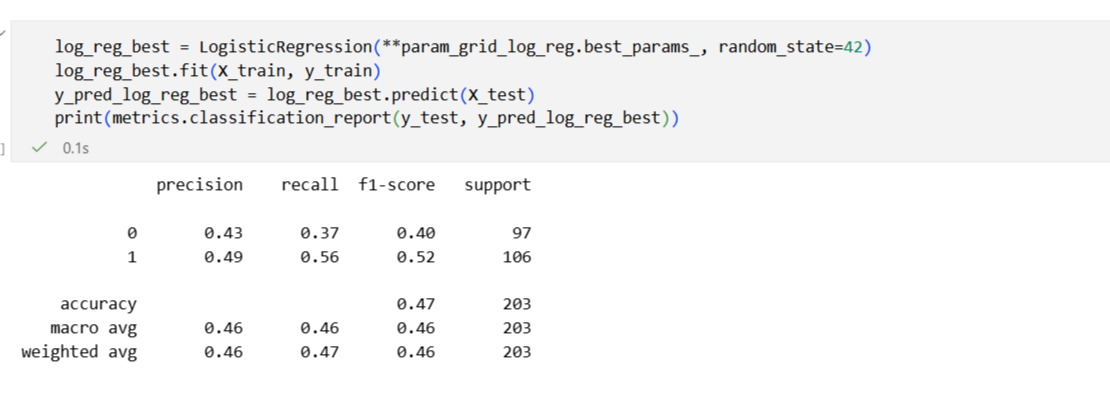

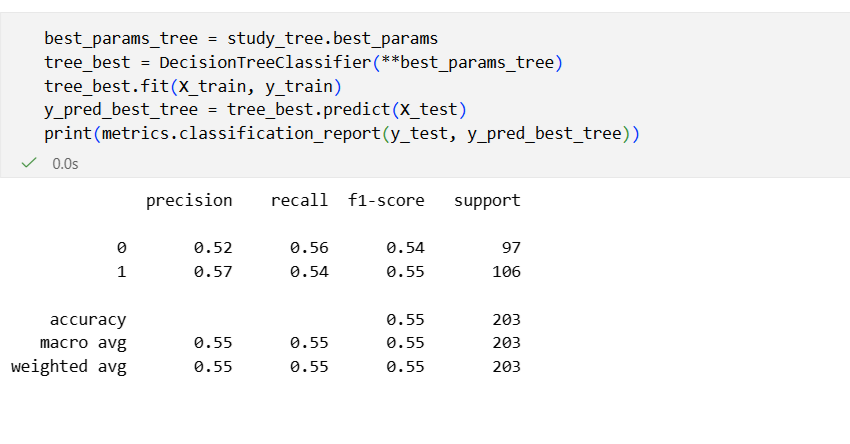

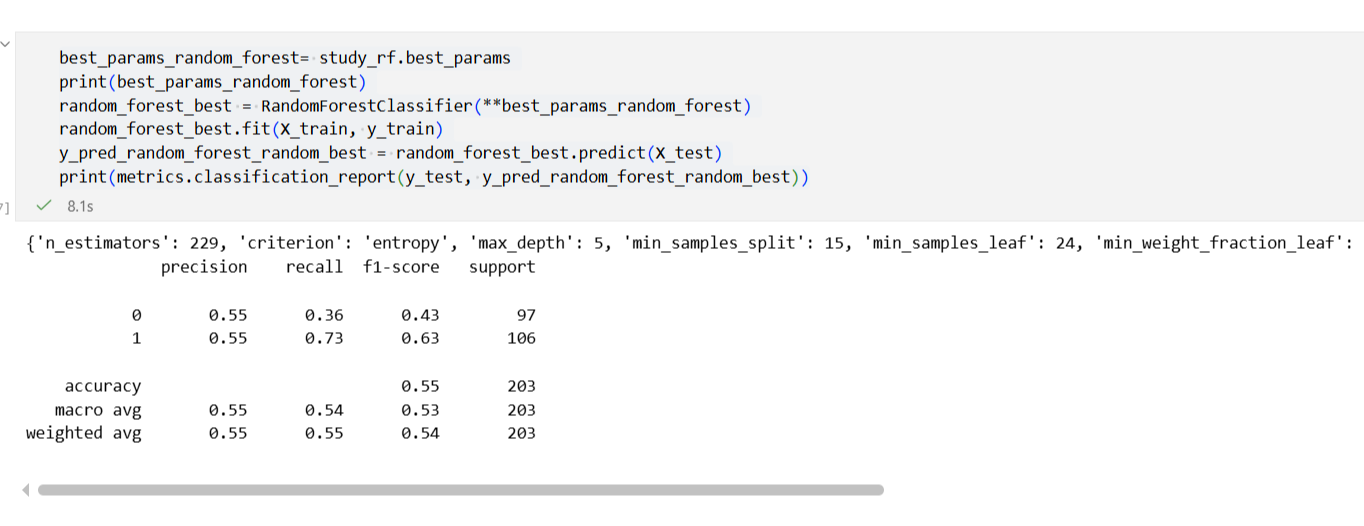

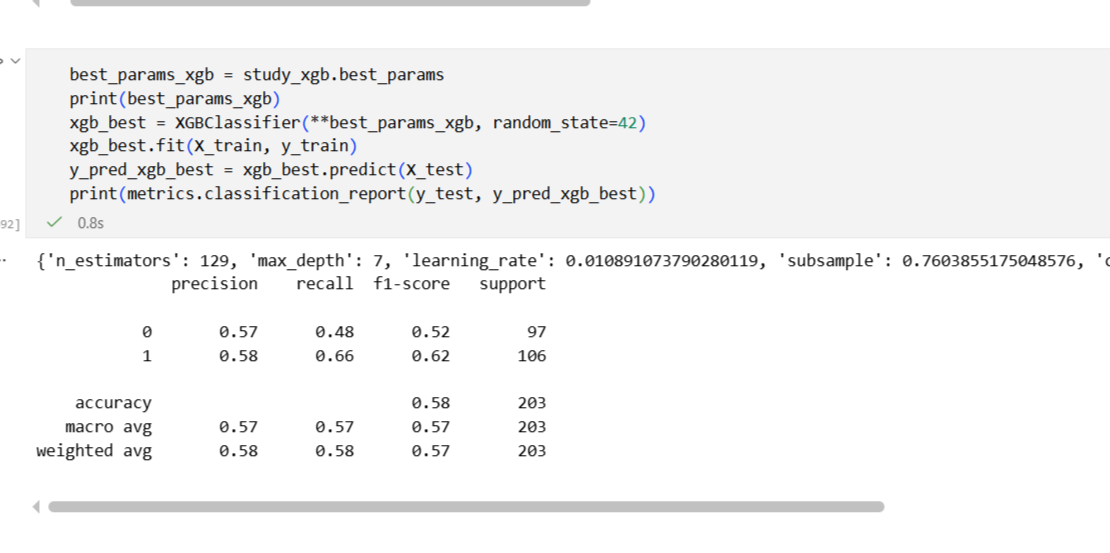

**С удалением**

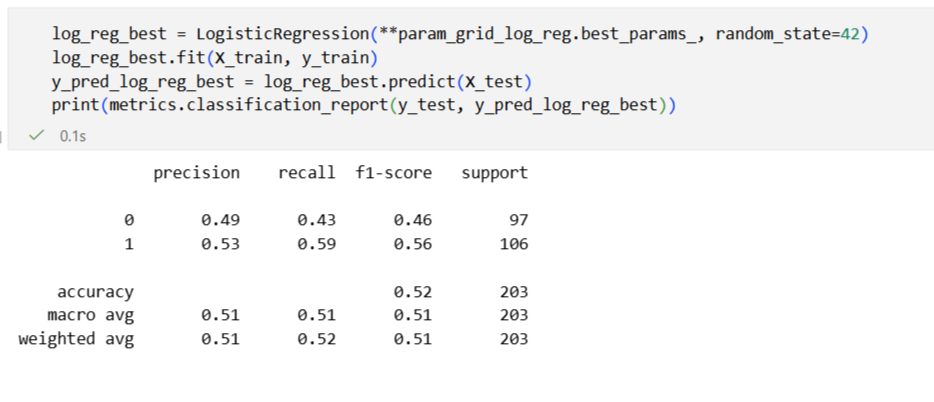

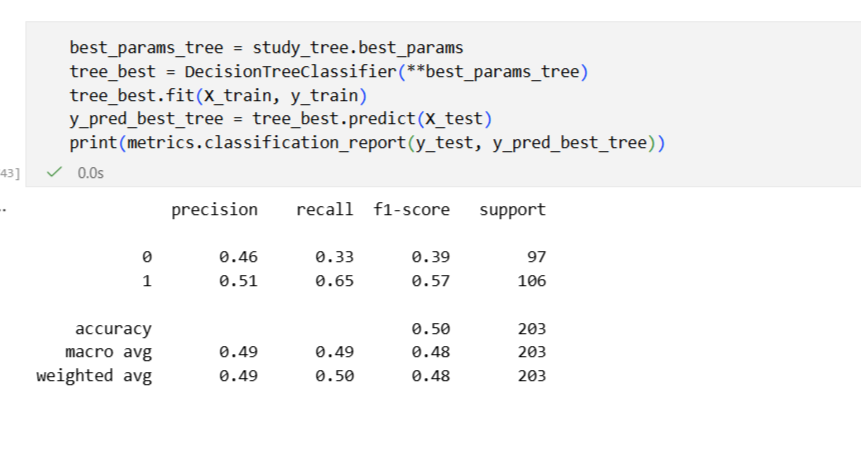

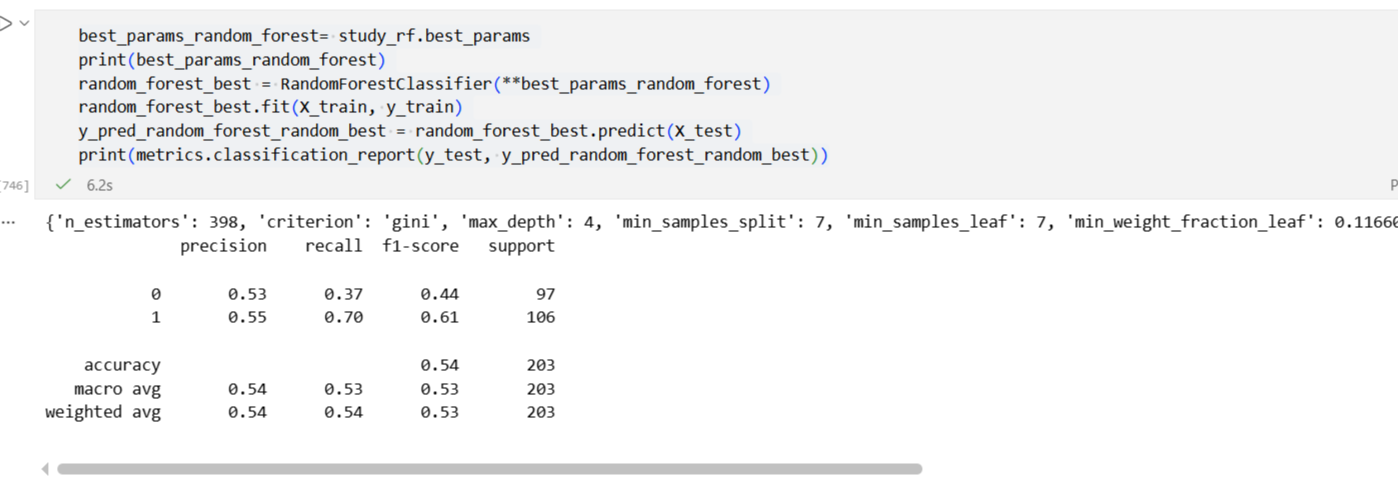

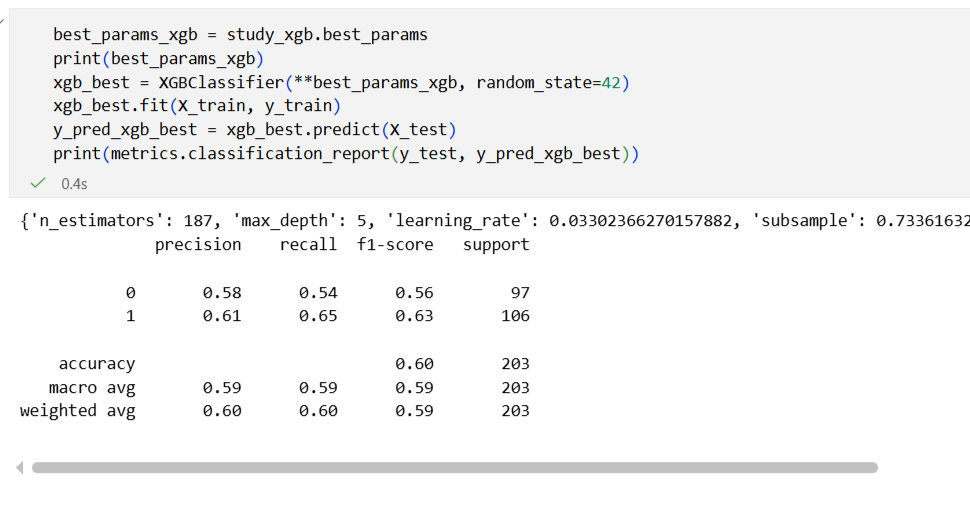